# OSD — Non-convex Finite-Set Component

When a component is known to take values in a **finite alphabet**
(e.g. a square wave in $\{-1,+1\}$), the corresponding cost is the indicator
of that set — a **non-convex** prior.  Proximal BCD still applies: the prox is
nearest-neighbour projection onto the alphabet.

This notebook follows the spirit of
`Simple_nonconvex_example-qss.ipynb` in the reference OSD repository.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import OSD
from pysdkit._osd import MeanSquareSmall, SmoothSecondDifference, FiniteSet

print(OSD())

Optimization-based Signal Decomposition (OSD)


## 1. Smooth + square + noise

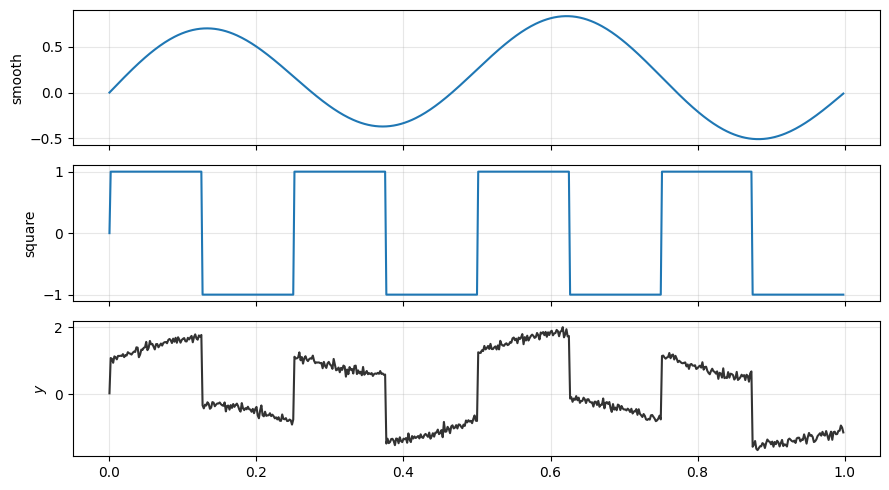

In [2]:
rng = np.random.default_rng(1)
T = 600
t = np.linspace(0, 1, T, endpoint=False)
smooth = 0.6 * np.sin(2 * np.pi * 2 * t) + 0.25 * np.sin(2 * np.pi * 0.5 * t)
square = np.sign(np.sin(2 * np.pi * 4 * t))
y = smooth + square + 0.08 * rng.standard_normal(T)

fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, smooth)
axes[0].set_ylabel("smooth")
axes[1].plot(t, square)
axes[1].set_ylabel("square")
axes[2].plot(t, y, color="0.2")
axes[2].set_ylabel("$y$")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Model

$$
x^0:\ \tfrac{1}{T}\|x\|_2^2,\qquad
x^1:\ \|D_2 x\|_2^2,\qquad
x^2:\ \mathbf{1}_{\{-1,+1\}}(x).
$$

In [3]:
osd = OSD.preset("nonconvex_square", length=T, max_iter=100)
X = osd.fit_transform(y)
print("unique values in finite-set component:", np.unique(np.round(X[2], 6)))
print("recon error:", np.max(np.abs(X.sum(0) - y)))

unique values in finite-set component: [-1.  1.]
recon error: 4.440892098500626e-16


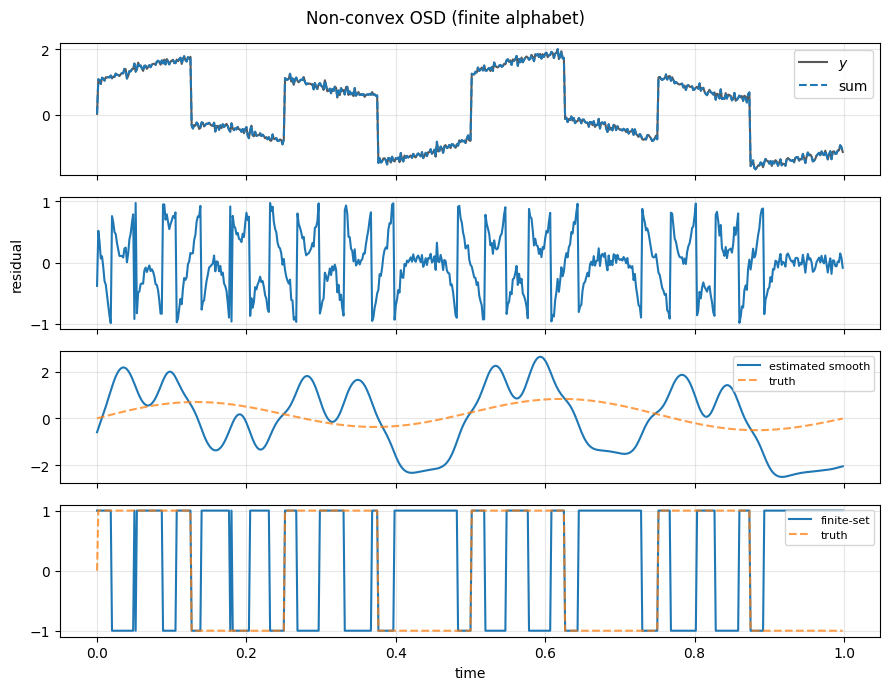

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t, y, color="0.35", label="$y$")
axes[0].plot(t, X.sum(0), "--", label="sum")
axes[0].legend(loc="upper right")
axes[1].plot(t, X[0])
axes[1].set_ylabel("residual")
axes[2].plot(t, X[1], label="estimated smooth")
axes[2].plot(t, smooth, "--", alpha=0.75, label="truth")
axes[2].legend(loc="upper right", fontsize=8)
axes[3].plot(t, X[2], label="finite-set")
axes[3].plot(t, square, "--", alpha=0.75, label="truth")
axes[3].legend(loc="upper right", fontsize=8)
axes[3].set_xlabel("time")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.suptitle("Non-convex OSD (finite alphabet)")
plt.tight_layout()
plt.show()

## 3. Compare with the convex TV model

Replacing `FiniteSet` by `SparseFirstDiffConvex` yields a convex relaxation
(soft square edges).

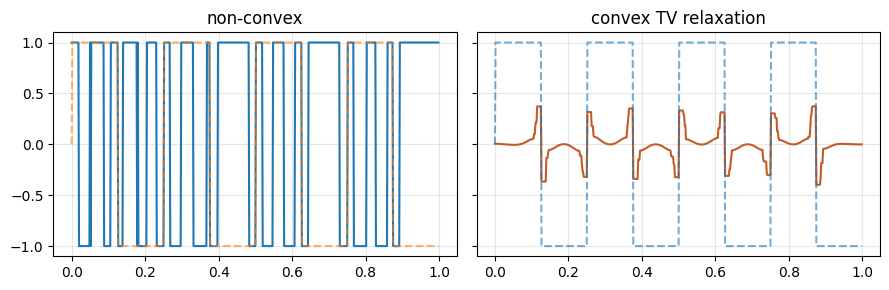

In [5]:
from pysdkit._osd import SparseFirstDiffConvex

convex = OSD(
    components=[
        MeanSquareSmall(size=T),
        SmoothSecondDifference(weight=1.0),
        SparseFirstDiffConvex(weight=2.0 / T, vmin=-1, vmax=1),
    ],
    max_iter=100,
)
Xc = convex.fit_transform(y)

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
axes[0].plot(t, X[2], label="FiniteSet")
axes[0].plot(t, square, "--", alpha=0.6)
axes[0].set_title("non-convex")
axes[1].plot(t, Xc[2], label="TV convex", color="#c45c26")
axes[1].plot(t, square, "--", alpha=0.6)
axes[1].set_title("convex TV relaxation")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. API reminder

```python
from pysdkit import OSD
from pysdkit._osd import MeanSquareSmall, SmoothSecondDifference, FiniteSet

osd = OSD(components=[...], max_iter=100)
X = osd.fit_transform(y)   # (K, N)
```